# 📊 Feature Engineering — Head 1 (CORD-v1)
## SnapBudget · CC26-PSU098

**Tujuan Notebook ini:**
Melakukan *feature engineering* pada dataset **CORD-v1** dari Hugging Face,
yaitu dataset berisi foto struk restoran Indonesia beserta informasi item yang dibeli.

**Alur kerja:**
1. Load dataset dari Hugging Face
2. Ekstrak nama item dari setiap struk
3. Buat fitur-fitur baru yang informatif
4. Beri label kategori (makanan, minuman, dll)
5. Gabungkan dengan dataset synthetic yang sudah ada
6. Simpan hasil akhir

**Output akhir:** File CSV siap pakai untuk melatih model klasifikasi kategori transaksi.

## ⚙️ Step 1 — Install Library

Sebelum mulai, kita perlu menginstall library tambahan yang tidak tersedia
secara default di Google Colab.

- **`datasets`** → library dari Hugging Face untuk mengunduh dan membaca dataset
  langsung dari internet tanpa perlu download manual.

> ⏳ Proses install hanya perlu dilakukan sekali per sesi Colab.
> Jika Colab di-restart, jalankan cell ini lagi.

In [1]:
# Install library yang dibutuhkan
!pip install datasets -q

print("✅ Instalasi selesai!")

✅ Instalasi selesai!


## 📥 Step 2 — Load Dataset CORD-v1 dari Hugging Face

Di sini kita mengunduh dataset **CORD-v1** langsung dari Hugging Face.

**Tentang dataset CORD-v1:**
- Berisi **1.000 foto struk** restoran dan kafe (mayoritas dari Indonesia)
- Setiap foto memiliki anotasi berformat JSON yang menyimpan:
  - `nm` → nama item yang dibeli (contoh: "Nasi Campur Bali")
  - `cnt` → jumlah item
  - `price` → harga item
- Dataset dibagi menjadi: **800 train**, **100 validation**, **100 test**

> ⚠️ Proses download membutuhkan waktu beberapa menit karena ukuran dataset ±2GB.
> Pastikan koneksi internet stabil.

In [2]:
from datasets import load_dataset
import json
import pandas as pd

# Load dataset CORD-v1 (akan download otomatis ~2GB, tunggu ya)
print("⏳ Loading dataset dari Hugging Face...")
dataset = load_dataset("naver-clova-ix/cord-v1")

print("✅ Dataset berhasil di-load!")
print(f"Jumlah data train : {len(dataset['train'])}")
print(f"Jumlah data test  : {len(dataset['test'])}")

# Lihat satu contoh
contoh = dataset['train'][0]
print("\n--- Contoh ground_truth ---")
gt = json.loads(contoh['ground_truth'])
print(json.dumps(gt, indent=2))

⏳ Loading dataset dari Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00004-4ecdadef88e06e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

...

data/test-00000-of-00001-f6c27485d73a032(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

✅ Dataset berhasil di-load!
Jumlah data train : 800
Jumlah data test  : 100

--- Contoh ground_truth ---
{
  "gt_parse": {
    "menu": [
      {
        "nm": "Nasi Campur Bali",
        "cnt": "x 1",
        "price": "75,000"
      },
      {
        "nm": "Bbk Bengil Nasi",
        "cnt": "x 1",
        "price": "125,000"
      },
      {
        "nm": "MilkShake Starwb",
        "cnt": "x 1",
        "price": "37,000"
      },
      {
        "nm": "Ice Lemon Tea",
        "cnt": "x 1",
        "price": "24,000"
      },
      {
        "nm": "Nasi Ayam Dewata",
        "cnt": "x 1",
        "price": "70,000"
      },
      {
        "nm": "Free Ice Tea",
        "cnt": "x 3",
        "price": "0"
      },
      {
        "nm": "Organic Green Sa",
        "cnt": "x 1",
        "price": "65,000"
      },
      {
        "nm": "Ice Tea",
        "cnt": "x 1",
        "price": "18,000"
      },
      {
        "nm": "Ice Orange",
        "cnt": "x 1",
        "price": "29,000"
      },

## 🔍 Step 3 — Ekstrak Nama Item dari Setiap Struk

Setiap struk menyimpan data dalam format **JSON** yang bentuknya seperti ini:

```json
{
  "gt_parse": {
    "menu": [
      {"nm": "Nasi Campur Bali", "cnt": "x1", "price": "75,000"},
      {"nm": "MilkShake Starwb", "cnt": "x1", "price": "37,000"},
      {"nm": "Ice Lemon Tea",    "cnt": "x1", "price": "24,000"}
    ]
  }
}
```

Yang kita butuhkan hanya nilai `nm` (nama item) dari setiap menu.

**Catatan penting:**
- Kolom `menu` kadang berupa **list** (banyak item), kadang berupa **dict** (satu item)
- Kita perlu menangani kedua kemungkinan ini agar tidak error
- Item kosong atau tidak valid akan diabaikan

In [3]:
def ekstrak_nama_item(ground_truth_str):
    """
    Mengambil semua nama item (nm) dari JSON ground truth struk
    """
    try:
        gt = json.loads(ground_truth_str)
        menu = gt.get('gt_parse', {}).get('menu', [])

        items = []

        # Menu bisa berupa list atau dict (satu item)
        if isinstance(menu, dict):
            menu = [menu]

        for item in menu:
            if isinstance(item, dict) and 'nm' in item:
                nama = item['nm'].strip()
                if nama:  # pastikan tidak kosong
                    items.append(nama)

        return items
    except:
        return []

# Ekstrak dari semua split (train + validation + test)
semua_items = []

for split in ['train', 'validation', 'test']:
    for row in dataset[split]:
        nama_items = ekstrak_nama_item(row['ground_truth'])
        semua_items.extend(nama_items)

print(f"✅ Total item berhasil diekstrak: {len(semua_items)}")
print("\nContoh 20 item pertama:")
for i, item in enumerate(semua_items[:20]):
    print(f"  {i+1}. {item}")

✅ Total item berhasil diekstrak: 2572

Contoh 20 item pertama:
  1. Nasi Campur Bali
  2. Bbk Bengil Nasi
  3. MilkShake Starwb
  4. Ice Lemon Tea
  5. Nasi Ayam Dewata
  6. Free Ice Tea
  7. Organic Green Sa
  8. Ice Tea
  9. Ice Orange
  10. Ayam Suir Bali
  11. Tahu Goreng
  12. Tempe Goreng
  13. Tahu Telor Asin
  14. Nasi Goreng Samb
  15. Bbk Panggang Sam
  16. Ayam Sambal Hija
  17. Hot Tea
  18. Ice Kopi
  19. Tahu Telor Asin
  20. Free Ice Tea


## 🗂️ Step 4 — Buat DataFrame Awal

Setelah semua nama item berhasil diekstrak dari seluruh struk,
kita gabungkan menjadi satu **DataFrame** (tabel data).

Pada langkah ini kita juga menghapus **duplikat** — item dengan nama
persis sama hanya disimpan satu kali, karena item yang sama
di struk berbeda tidak menambah informasi baru untuk model.

In [4]:
# Buat dataframe dari semua item yang diekstrak
df = pd.DataFrame({'text': semua_items})

# Hapus duplikat persis sama
df = df.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Total item unik: {len(df)}")
print(df.head(10))

Total item unik: 1727
               text
0  Nasi Campur Bali
1   Bbk Bengil Nasi
2  MilkShake Starwb
3     Ice Lemon Tea
4  Nasi Ayam Dewata
5      Free Ice Tea
6  Organic Green Sa
7           Ice Tea
8        Ice Orange
9    Ayam Suir Bali


## 🛠️ Step 5 — Feature Engineering (Bagian Utama)

Ini adalah langkah terpenting dalam notebook ini.

**Apa itu Feature Engineering?**
Proses mengubah data mentah (teks nama item) menjadi angka-angka
yang bisa "dimengerti" oleh model machine learning.

**Fitur yang akan di buat:**

| No | Fitur | Penjelasan |
|----|-------|------------|
| 1 | `text_clean` | Teks nama item yang sudah dibersihkan (huruf kecil semua, karakter aneh dihapus) |
| 2 | `panjang_karakter` | Jumlah karakter dalam nama item |
| 3 | `jumlah_kata` | Jumlah kata dalam nama item |
| 4 | `ada_angka` | Apakah nama item mengandung angka? (misal: "1001-Choco Bun") |
| 5 | `kata_makanan` | Apakah nama item mengandung kata kunci makanan? |
| 6 | `kata_minuman` | Apakah nama item mengandung kata kunci minuman? |
| 7 | `kata_transportasi` | Apakah nama item mengandung kata kunci transportasi? |
| 8 | `kata_belanja` | Apakah nama item mengandung kata kunci belanja? |
| 9 | `kata_tagihan` | Apakah nama item mengandung kata kunci tagihan? |
| 10 | `kata_hiburan` | Apakah nama item mengandung kata kunci hiburan? |
| 11 | `kata_kesehatan` | Apakah nama item mengandung kata kunci kesehatan? |
| 12 | `jumlah_kata_kunci_cocok` | Total berapa kategori yang cocok (0 = tidak cocok sama sekali) |
| 13 | `semua_kapital` | Apakah semua huruf kapital? (banyak struk memakai HURUF KAPITAL) |

> 💡 Fitur berbasis kata kunci bekerja dengan cara sederhana:
> jika nama item mengandung kata "kopi" atau "teh", maka `kata_minuman = 1`, sisanya `0`.

In [5]:
import re

# ── FITUR 1: Teks bersih (lowercase, hapus karakter aneh) ──────────────
df['text_clean'] = (df['text']
                    .str.lower()
                    .str.strip()
                    .str.replace(r'[^a-z0-9\s]', ' ', regex=True)
                    .str.replace(r'\s+', ' ', regex=True)
                    .str.strip())

# ── FITUR 2: Panjang teks (jumlah karakter) ────────────────────────────
df['panjang_karakter'] = df['text_clean'].str.len()

# ── FITUR 3: Jumlah kata ───────────────────────────────────────────────
df['jumlah_kata'] = df['text_clean'].str.split().str.len()

# ── FITUR 4: Apakah ada angka (kode produk seperti "1001-Choco Bun") ───
df['ada_angka'] = df['text'].str.contains(r'\d', regex=True).astype(int)

# ── FITUR 5: Kata kunci per kategori ──────────────────────────────────
kata_kunci = {
    'makanan': [
        'nasi', 'ayam', 'mie', 'mi', 'burger', 'soto', 'bakso', 'sate',
        'rendang', 'gado', 'capcay', 'pasta', 'pizza', 'sandwich', 'roti',
        'kentang', 'nugget', 'rice', 'chicken', 'beef', 'fish', 'ikan',
        'udang', 'cumi', 'babi', 'sapi', 'kambing', 'tahu', 'tempe',
        'sayur', 'soup', 'sop', 'rawon', 'pecel', 'ketoprak', 'lontong',
        'bubur', 'dimsum', 'siomay', 'pempek', 'lasagna', 'steak',
        'meatball', 'baso', 'baso', 'hakau', 'dumplings', 'wonton',
        'noodle', 'fried', 'bakar', 'goreng', 'rebus', 'panggang',
        'salad', 'sushi', 'ramen', 'udon', 'pho', 'crepes', 'waffle',
        'donut', 'bun', 'toast', 'cake', 'pie', 'cookie', 'crackers'
    ],
    'minuman': [
        'kopi', 'coffee', 'teh', 'tea', 'jus', 'juice', 'air', 'water',
        'milk', 'susu', 'boba', 'latte', 'cappuccino', 'espresso',
        'americano', 'matcha', 'chocolate', 'coklat', 'milkshake',
        'smoothie', 'soda', 'cola', 'sprite', 'fanta', 'es', 'ice',
        'lemon', 'jeruk', 'mangga', 'sirup', 'minuman', 'drink',
        'beverage', 'thai', 'grentea', 'green tea', 'iced', 'hot',
        'frappe', 'macchiato', 'mocha', 'infused', 'tonic', 'beer',
        'ades', 'pocari', 'aqua', 'mineral', 'yakult'
    ],
    'transportasi': [
        'grab', 'gojek', 'ojek', 'bensin', 'parkir', 'parking', 'bus',
        'mrt', 'lrt', 'kereta', 'taxi', 'taksi', 'toll', 'tol',
        'tiket', 'ticket', 'transport', 'uber', 'kendaraan', 'motor',
        'mobil', 'angkot', 'transjakarta', 'commuter', 'bbm', 'solar'
    ],
    'belanja': [
        'plastik', 'plastic', 'bag', 'tas', 'packaging', 'baju',
        'kaos', 'celana', 'sepatu', 'sandal', 'aksesoris', 'jam',
        'sabun', 'shampoo', 'deterjen', 'tissue', 'pembalut',
        'alat', 'peralatan', 'elektronik', 'charger', 'kabel',
        'sendok', 'garpu', 'piring', 'gelas', 'botol', 'item'
    ],
    'tagihan': [
        'tagihan', 'listrik', 'electricity', 'air', 'water', 'pdam',
        'internet', 'wifi', 'telpon', 'phone', 'pulsa', 'token',
        'bpjs', 'asuransi', 'insurance', 'cicilan', 'angsuran',
        'sewa', 'rent', 'iuran', 'pajak', 'tax', 'service charge',
        'admin', 'biaya'
    ],
    'hiburan': [
        'bioskop', 'cinema', 'film', 'movie', 'game', 'gaming',
        'karaoke', 'bowling', 'billiard', 'gym', 'fitness',
        'tiket', 'ticket', 'konser', 'concert', 'hiburan',
        'entertainment', 'wahana', 'playground', 'theme park',
        'spa', 'massage', 'salon', 'fotografi', 'photography'
    ],
    'kesehatan': [
        'obat', 'medicine', 'vitamin', 'suplemen', 'supplement',
        'apotek', 'pharmacy', 'dokter', 'doctor', 'klinik', 'clinic',
        'rumah sakit', 'hospital', 'laboratorium', 'lab', 'konsultasi',
        'periksa', 'resep', 'prescription', 'masker', 'mask',
        'sanitizer', 'antiseptik', 'termometer', 'tensi'
    ]
}

# Buat kolom fitur untuk setiap kategori
for kategori, kata_list in kata_kunci.items():
    df[f'kata_{kategori}'] = df['text_clean'].apply(
        lambda x: int(any(kata in x for kata in kata_list))
    )

# ── FITUR 6: Hitung berapa kategori yang cocok ─────────────────────────
kolom_kata = [f'kata_{k}' for k in kata_kunci.keys()]
df['jumlah_kata_kunci_cocok'] = df[kolom_kata].sum(axis=1)

# ── FITUR 7: Teks dimulai dengan huruf kapital semua (sering = nama produk)
df['semua_kapital'] = df['text'].apply(
    lambda x: int(x.isupper())
)

print("✅ Feature engineering selesai!")
print(f"\nTotal fitur baru: {len(df.columns) - 1}")
print("\nPreview dataframe:")
display(df.head(10))
print("\nSemua kolom:")
print(df.columns.tolist())

✅ Feature engineering selesai!

Total fitur baru: 13

Preview dataframe:


,text,text_clean,panjang_karakter,jumlah_kata,ada_angka,kata_makanan,kata_minuman,kata_transportasi,kata_belanja,kata_tagihan,kata_hiburan,kata_kesehatan,jumlah_kata_kunci_cocok,semua_kapital
0,Nasi Campur Bali,nasi campur bali,16,3,0,1,0,0,0,0,0,0,1,0
1,Bbk Bengil Nasi,bbk bengil nasi,15,3,0,1,0,0,0,0,0,0,1,0
2,MilkShake Starwb,milkshake starwb,16,2,0,1,1,0,0,0,0,0,2,0
3,Ice Lemon Tea,ice lemon tea,13,3,0,0,1,0,0,0,0,0,1,0
4,Nasi Ayam Dewata,nasi ayam dewata,16,3,0,1,0,0,0,0,0,0,1,0
5,Free Ice Tea,free ice tea,12,3,0,0,1,0,0,0,0,0,1,0
6,Organic Green Sa,organic green sa,16,3,0,0,0,0,0,0,0,0,0,0
7,Ice Tea,ice tea,7,2,0,0,1,0,0,0,0,0,1,0
8,Ice Orange,ice orange,10,2,0,0,1,0,0,0,0,0,1,0
9,Ayam Suir Bali,ayam suir bali,14,3,0,1,0,0,0,0,0,0,1,0



Semua kolom:
['text', 'text_clean', 'panjang_karakter', 'jumlah_kata', 'ada_angka', 'kata_makanan', 'kata_minuman', 'kata_transportasi', 'kata_belanja', 'kata_tagihan', 'kata_hiburan', 'kata_kesehatan', 'jumlah_kata_kunci_cocok', 'semua_kapital']


## 🏷️ Step 6 — Labeling Otomatis Berdasarkan Kata Kunci

Setelah fitur dibuat, kita perlu memberikan **label kategori** pada setiap item.

**Cara kerja labeling:**
- Sistem memeriksa fitur kata kunci yang sudah dibuat di Step 5
- Jika ada lebih dari satu kategori yang cocok, sistem memilih berdasarkan **urutan prioritas**:
  1. Minuman (paling mudah dikenali)
  2. Makanan
  3. Transportasi
  4. Kesehatan
  5. Hiburan
  6. Tagihan
  7. Belanja
- Jika **tidak ada** kata kunci yang cocok → otomatis masuk `lain_lain`

**Mapping label ke angka** (sama dengan dataset synthetic):

| Kategori | label_id |
|----------|----------|
| makanan | 0 |
| minuman | 1 |
| transportasi | 2 |
| belanja | 3 |
| tagihan | 4 |
| hiburan | 5 |
| kesehatan | 6 |
| lain_lain | 7 |

In [6]:
# Mapping kategori ke label_id (sama persis dengan CSV synthetic)
KATEGORI_MAP = {
    'makanan': 0,
    'minuman': 1,
    'transportasi': 2,
    'belanja': 3,
    'tagihan': 4,
    'hiburan': 5,
    'kesehatan': 6,
    'lain_lain': 7
}

def tentukan_kategori(row):
    """
    Tentukan kategori berdasarkan fitur kata kunci.
    Kalau ada lebih dari 1 kategori cocok, ambil yang paling relevan.
    Kalau tidak ada yang cocok, masuk lain_lain.
    """
    # Prioritas berdasarkan kata kunci
    prioritas = ['minuman', 'makanan', 'transportasi',
                 'kesehatan', 'hiburan', 'tagihan', 'belanja']

    for kat in prioritas:
        if row[f'kata_{kat}'] == 1:
            return kat

    return 'lain_lain'

# Terapkan labeling
df['category'] = df.apply(tentukan_kategori, axis=1)
df['label_id'] = df['category'].map(KATEGORI_MAP)

# Lihat distribusi
print("✅ Labeling selesai!")
print("\nDistribusi kategori:")
print(df['category'].value_counts())
print(f"\nTotal data berlabel: {len(df)}")

✅ Labeling selesai!

Distribusi kategori:
category
lain_lain       746
minuman         500
makanan         419
belanja          43
transportasi     12
hiburan           5
tagihan           1
kesehatan         1
Name: count, dtype: int64

Total data berlabel: 1727


## 📊 Step 7 — Visualisasi Distribusi Kategori

Sebelum lanjut, kita perlu memeriksa apakah distribusi kategori seimbang atau tidak.

**Mengapa ini penting?**
Jika satu kategori jauh lebih banyak dari yang lain (misalnya makanan = 80%,
sedangkan tagihan = 1%), model akan cenderung "malas" dan selalu menebak makanan.
Ini disebut **class imbalance**.

Dari visualisasi ini kita bisa menentukan apakah perlu langkah tambahan
seperti:
- **Oversampling** → memperbanyak data kategori yang sedikit
- **Undersampling** → mengurangi data kategori yang terlalu banyak
- **Menambah kata kunci** → jika ada kategori yang hasilnya terlalu sedikit

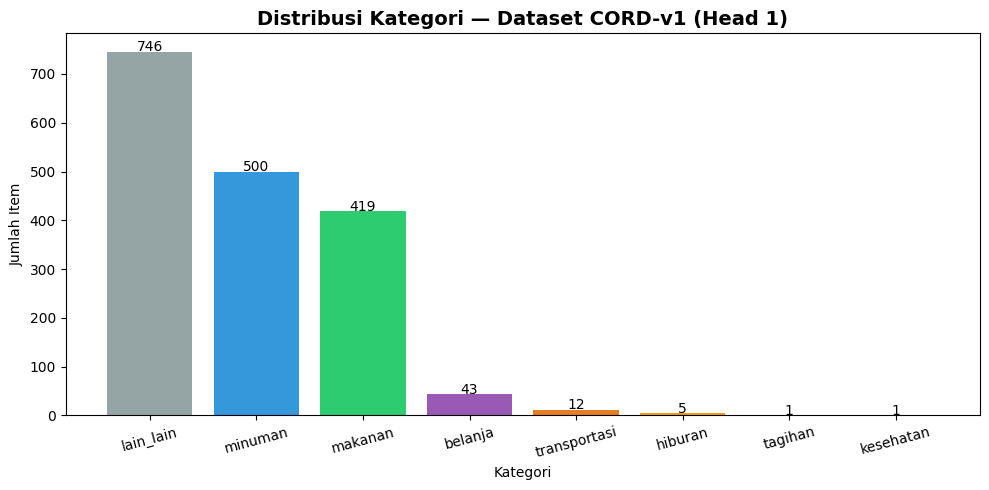

In [7]:
import matplotlib.pyplot as plt

# Hitung distribusi
distribusi = df['category'].value_counts()

# Warna per kategori
warna = {
    'makanan': '#2ECC71',
    'minuman': '#3498DB',
    'transportasi': '#E67E22',
    'belanja': '#9B59B6',
    'tagihan': '#E74C3C',
    'hiburan': '#F39C12',
    'kesehatan': '#1ABC9C',
    'lain_lain': '#95A5A6'
}

colors = [warna.get(k, '#CCCCCC') for k in distribusi.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(distribusi.index, distribusi.values, color=colors)
plt.title('Distribusi Kategori — Dataset CORD-v1 (Head 1)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Item')
plt.xticks(rotation=15)

# Tambah angka di atas bar
for bar, val in zip(bars, distribusi.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('distribusi_head1.png', dpi=100)
plt.show()

## 🔗 Step 8 — Gabungkan dengan Dataset Synthetic

Kita menggabungkan dua dataset:

| Dataset | Sumber | Isi |
|---------|--------|-----|
| `synthetic_dataset_head1c.csv` | Dibuat oleh tim AI | 9.600 item dengan label sudah tersedia |
| Dataset CORD-v1 | Hugging Face (foto struk nyata) | Item dari struk restoran Indonesia |

**Manfaat menggabungkan keduanya:**
- Dataset synthetic → banyak dan bervariasi, tapi dibuat secara buatan
- Dataset CORD-v1 → data nyata dari struk asli, lebih representatif
- Gabungan keduanya → model yang lebih **robust** dan akurat

> 📌 Upload file `synthetic_dataset_head1c.csv` ketika diminta.

In [8]:
# Upload dulu file synthetic_dataset_head1c.csv
from google.colab import files
print("Upload file synthetic_dataset_head1c.csv")
uploaded = files.upload()

df_synthetic = pd.read_csv('synthetic_dataset_head1c.csv')

# Samakan format kolom
df_cord = df[['text', 'label_id', 'category']].copy()
df_cord['sumber'] = 'cord_v1'
df_synthetic['sumber'] = 'synthetic'

# Gabungkan
df_gabungan = pd.concat([df_synthetic, df_cord], ignore_index=True)
df_gabungan = df_gabungan.drop_duplicates(subset='text').reset_index(drop=True)

print(f"Dataset synthetic : {len(df_synthetic)} baris")
print(f"Dataset CORD-v1   : {len(df_cord)} baris")
print(f"Dataset gabungan  : {len(df_gabungan)} baris")
print("\nPreview:")
display(df_gabungan.head(10))

Upload file synthetic_dataset_head1c.csv


Saving synthetic_dataset_head1c.csv to synthetic_dataset_head1c.csv
Dataset synthetic : 9600 baris
Dataset CORD-v1   : 1727 baris
Dataset gabungan  : 3707 baris

Preview:


,text,label_id,category,sumber
0,Sabun,3,belanja,synthetic
1,Cappuccino,1,minuman,synthetic
2,GrabExpress,7,lain_lain,synthetic
3,Donasi,7,lain_lain,synthetic
4,TENIS,5,hiburan,synthetic
5,Grab,2,transportasi,synthetic
6,Nonton Film,5,hiburan,synthetic
7,Risotto,0,makanan,synthetic
8,Dokter,6,kesehatan,synthetic
9,Wahana,5,hiburan,synthetic


## 💾 Step 9 — Simpan Hasil Akhir

Di langkah terakhir ini kita menyimpan dua file hasil kerja kita:

| File | Isi |
|------|-----|
| `head1_cord_engineered.csv` | Data CORD-v1 lengkap dengan semua fitur baru |
| `head1_gabungan_final.csv` | Gabungan dataset synthetic + CORD-v1, siap dipakai untuk training model |

**File `head1_gabungan_final.csv` inilah yang akan digunakan oleh tim AI**
sebagai input untuk melatih model klasifikasi kategori transaksi di SnapBudget.

> ✅ Setelah cell ini dijalankan, file akan otomatis terdownload ke komputer.

In [9]:
# Simpan dataset lengkap dengan semua fitur
df_fitur_lengkap = df[['text', 'text_clean', 'label_id', 'category',
                        'panjang_karakter', 'jumlah_kata', 'ada_angka',
                        'semua_kapital', 'jumlah_kata_kunci_cocok'] + kolom_kata]

df_fitur_lengkap.to_csv('head1_cord_engineered.csv', index=False)

# Simpan juga dataset gabungan
df_gabungan.to_csv('head1_gabungan_final.csv', index=False)

# Download ke komputer kamu
files.download('head1_cord_engineered.csv')
files.download('head1_gabungan_final.csv')

print("✅ Semua file berhasil disimpan dan didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file berhasil disimpan dan didownload!


## ✅ Selesai! Ringkasan Hasil Feature Engineering

**Yang sudah lakukan:**
1. ✅ Load 1.000 foto struk dari dataset CORD-v1 (Hugging Face)
2. ✅ Ekstrak nama item dari setiap struk menggunakan parsing JSON
3. ✅ Membuat 13 fitur baru dari nama item mentah
4. ✅ Memberi label kategori secara otomatis menggunakan kata kunci
5. ✅ Menggabungkan dengan dataset synthetic yang sudah ada
6. ✅ Menyimpan hasil akhir dalam format CSV

**File yang dihasilkan:**
- `head1_cord_engineered.csv` → data CORD dengan fitur lengkap
- `head1_gabungan_final.csv` → dataset final siap untuk training model

**Langkah selanjutnya (dikerjakan tim AI):**
Model klasifikasi akan dilatih menggunakan file `head1_gabungan_final.csv`
untuk memprediksi kategori setiap item transaksi di aplikasi **SnapBudget**.